In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

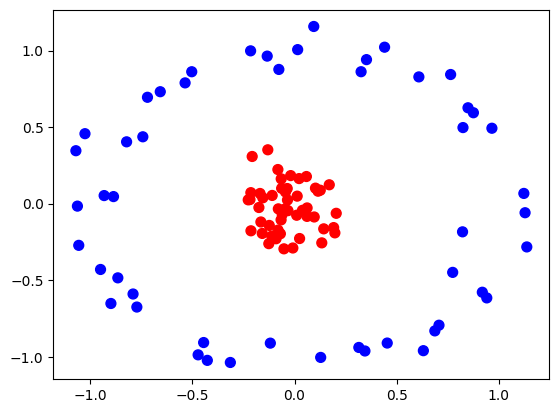

In [45]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [47]:
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5

In [49]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                stop = X_set[:, 0].max() + 1, 
                                step = 0.01),
                        np.arange(start = X_set[:, 1].min() - 1, 
                                stop = X_set[:, 1].max() + 1, 
                                step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                            X2.ravel()]).T).reshape(X1.shape),
                                            alpha = 0.75, 
                                            cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color = zero_one_colourmap(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

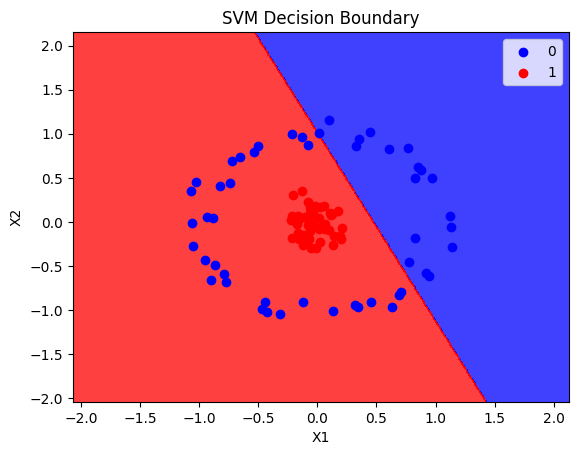

In [50]:
plot_decision_boundary(X, y, classifier)

### Lets increase the dimension of the data to 3D and see if we can find a linear decision boundary in that space.

In [51]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

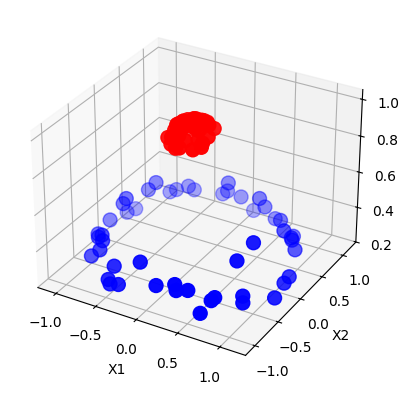

In [52]:
plot_3d_plot(X,y)

In [53]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [54]:
accuracy_score(y_test, y_pred)

1.0

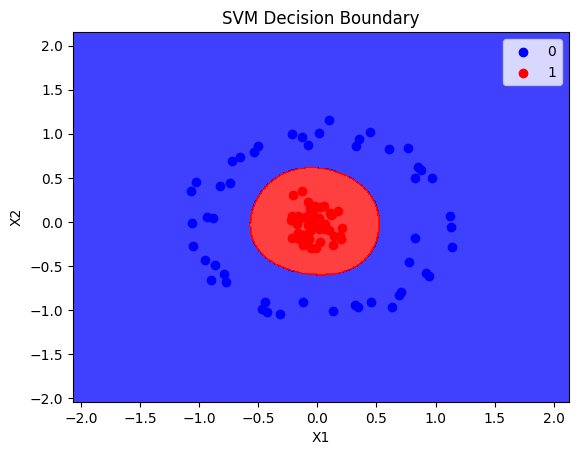

In [55]:
plot_decision_boundary(X, y, rbf_classifier)

In [56]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [57]:
accuracy_score(y_test, y_pred)

1.0

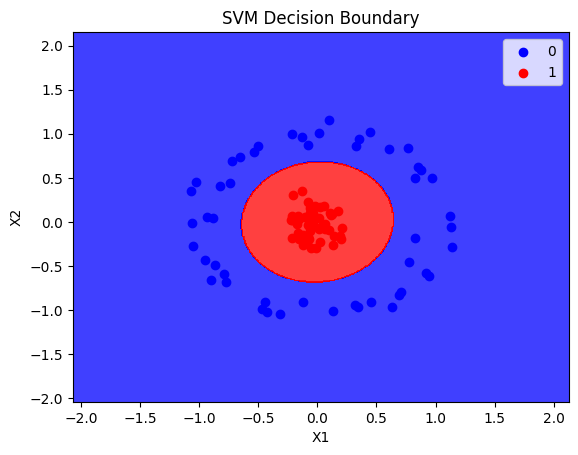

In [58]:
plot_decision_boundary(X, y, poly_classifier)

In [59]:
X

array([[ 0.32608671,  0.86226485],
       [ 0.19771027, -0.19082937],
       [-0.79080005, -0.59039422],
       [ 0.31504268, -0.93967745],
       [-0.06577959, -0.10586476],
       [ 0.34489792, -0.9627433 ],
       [-0.05178635, -0.2951887 ],
       [ 0.87618272,  0.5942267 ],
       [ 0.20431523, -0.06299842],
       [-1.0567356 , -0.27234944],
       [-0.16466954, -0.11961868],
       [ 1.13772705, -0.28274138],
       [-0.20731366,  0.30837593],
       [-0.04416257,  0.0766223 ],
       [ 0.7076033 , -0.7943463 ],
       [-0.21337407, -0.17731725],
       [ 0.45408078, -0.91091492],
       [-0.03442196,  0.02411339],
       [ 0.01065389, -0.07566301],
       [ 0.02488734, -0.22781527],
       [-0.77219039, -0.67561263],
       [ 0.60909959,  0.82841505],
       [-0.15788513, -0.19454003],
       [-0.00817016, -0.28972832],
       [ 0.76465961,  0.84407517],
       [-0.01877076,  0.18346567],
       [-0.06304205,  0.10029837],
       [-0.0320951 , -0.04558091],
       [ 0.3525528 ,

In [60]:
np.exp(-(X**2)).sum(1)

array([1.37457222, 1.92590401, 1.24076606, 1.31905762, 1.98453761,
       1.28363689, 1.91387386, 1.16658417, 1.95515366, 1.25587144,
       1.95904154, 1.19722524, 1.86721745, 1.99219779, 1.13817166,
       1.92454011, 1.24983033, 1.99823454, 1.99417797, 1.94880481,
       1.18438527, 1.19349203, 1.9382418 , 1.91941738, 1.04770543,
       1.96654825, 1.98602425, 1.99689497, 1.29536262, 1.97295294,
       1.99672823, 1.21203684, 1.17700945, 1.91824309, 1.17461674,
       1.98521913, 1.12443448, 1.96745675, 1.14431843, 1.96408073,
       1.26347274, 1.36609949, 1.96482131, 1.95014152, 1.45353039,
       1.98935653, 1.17698508, 1.25170241, 1.96940463, 1.86644508,
       1.09630311, 1.47465645, 1.42173792, 1.97471396, 1.18366826,
       1.32259804, 1.16007081, 1.95631319, 1.99259072, 1.27867418,
       1.06877371, 1.25275132, 1.95277972, 1.98896367, 1.37689584,
       1.97927908, 1.98318494, 1.95302231, 1.35776811, 1.91879988,
       1.94929625, 1.93977691, 1.94356256, 1.28666572, 1.32362

In [61]:
X_new=np.exp(-(X**2))

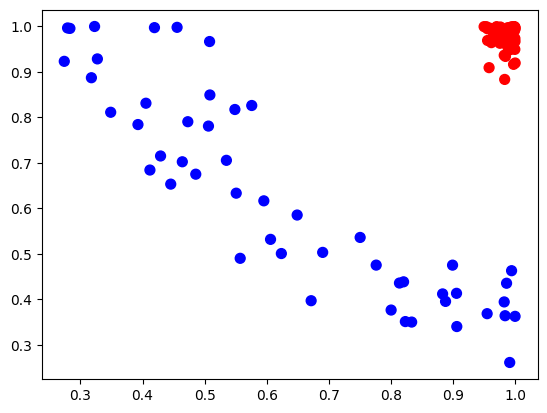

In [62]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')